Pre-requisite:

    I used code from the lecture to generate 2 Ethereum testnet addresses:

    Private Key: fb0b2c6716c6d6905f48813f60c74166647430351963d8886a068ecbe2afecee
    Checksum Address: 0x3573128e3bA65Dac6711E7a42d9C4eC0AD347426

    Private Key: 30365fe5503be8e01a619105516ae91ca99e2323deadb48257bd43499a658f88
    Checksum Address: 0xB3500576DA2f9Ae0EE81aF3FE9dafEd7c5377D43

In [36]:
address_1 = "0x3573128e3bA65Dac6711E7a42d9C4eC0AD347426"
address_2 = "0xB3500576DA2f9Ae0EE81aF3FE9dafEd7c5377D43"
private_key_1 = "fb0b2c6716c6d6905f48813f60c74166647430351963d8886a068ecbe2afecee"
private_key_2 = "30365fe5503be8e01a619105516ae91ca99e2323deadb48257bd43499a658f88"

1 task:

In [5]:
from web3 import Web3

MAINNET_RPC = "https://mainnet.infura.io/v3/61e6d1a1fad442c5a5c96721a8e53304"   #infura
SEPOLIA_RPC = "https://sepolia.infura.io/v3/61e6d1a1fad442c5a5c96721a8e53304"   #infura  
HOODI_RPC = "https://eth-hoodi.g.alchemy.com/v2/CmmSNgFuASuMw21tGmvbq"  #alchemy
GANACHE_RPC = "http://127.0.0.1:7545"

print("Choose network:\n"
      "  1. mainnet\n"
      "  2. sepolia\n"
      "  3. hoodi\n"
      "  4. ganache")

RPC = None
net_name = None
while True:
    choice = input("Write number (1-4): ").strip()
    if choice == "1":
        RPC, net_name = MAINNET_RPC, "mainnet"
        break
    elif choice == "2":
        RPC, net_name = SEPOLIA_RPC, "sepolia"
        break
    elif choice == "3":
        RPC, net_name = HOODI_RPC, "hoodi"
        break
    elif choice == "4":
        RPC, net_name = GANACHE_RPC, "ganache"
        break
    else:
        print("Choose number (1-4)")

w3 = Web3(Web3.HTTPProvider(RPC, request_kwargs={"timeout": 10}))
if w3.is_connected():
    print(f"Success: {net_name} connected via {RPC}")
else:
    print(f"Fail: {net_name} connected via {RPC}")


Choose network:
  1. mainnet
  2. sepolia
  3. hoodi
  4. ganache
Success: mainnet connected via https://mainnet.infura.io/v3/61e6d1a1fad442c5a5c96721a8e53304


2 task:

In [ ]:
web3 = Web3(Web3.HTTPProvider(SEPOLIA_RPC))
print(web3.eth.get_balance(address_1),'Wei')

0 Wei


Let's get some Ethereum test coins using cloud.google

In [7]:
print(web3.eth.get_balance(address_1),'Wei')

50000000000000000 Wei


3 task:

In [19]:
height = web3.eth.block_number
print("Block height:", height)

Block height: 9495123


In [35]:
from datetime import datetime, timezone

print("Choose block:\n"
      "  1. latest\n"
      "  2. finalized\n"
      "  3. safe\n"
      "  4. pending\n"
      "  5. earliest\n"
      "  6. Write block number\n"
      "  7. Write block hash")

while True:
    choice = input("Write number (1-7): ").strip()
    if choice == "1":
        block_identifier = "latest"
        break
    elif choice == "2":
        block_identifier = "finalized"
        break
    elif choice == "3":
        block_identifier = "safe"
        break
    elif choice == "4":
        block_identifier = "pending"
        break
    elif choice == "5":
        block_identifier = "earliest"
        break
    elif choice == "6":
        block_identifier = int(input("Enter block number: ").strip())
        break
    elif choice == "7":
        block_identifier = input("Enter block hash (0x...): ").strip()
        break
    else:
        print("Please enter a number from 1 to 7.")

try:
    blk = web3.eth.get_block(block_identifier)

    info = {
        "number": getattr(blk, "number", None),
        "hash": blk.hash.hex() if getattr(blk, "hash", None) else None,
        "parentHash": blk.parentHash.hex() if getattr(blk, "parentHash", None) else None,
        "timestamp": getattr(blk, "timestamp", None),
        "datetime_utc": datetime.fromtimestamp(blk.timestamp, tz=timezone.utc).isoformat() if getattr(blk, "timestamp", None) else None,
        "tx_count": len(blk.transactions),
        "gasUsed": getattr(blk, "gasUsed", None),
        "baseFeePerGas": getattr(blk, "baseFeePerGas", None),
    }

    print("\n────────── Block info ──────────")
    for key, value in info.items():
        print(f"{key:<15}: {value}")
    print("────────────────────────────────")

except Exception as e:
    print("Error: ", e)

Choose block:
  1. latest
  2. finalized
  3. safe
  4. pending
  5. earliest
  6. Write block number
  7. Write block hash

────────── Block info ──────────
number         : 9495223
hash           : f55792c0ad2fa8ab286e265d0ea6f0091417cb6aea5c402c9061adb57a3f447b
parentHash     : f42b667a8a04cebb5107e1c4bc018fcb1221f1f3c86bffdfd28e351b15a6597f
timestamp      : 1761492552
datetime_utc   : 2025-10-26T15:29:12+00:00
tx_count       : 135
gasUsed        : 12157040
baseFeePerGas  : 9
────────────────────────────────


In [22]:
bal_wei = web3.eth.get_balance(address_1)
bal_eth = web3.from_wei(bal_wei, "ether")
print(bal_eth, "ETH")

0.05 ETH


4 task:

In [37]:
tx = {
      'nonce':web3.eth.get_transaction_count(address_1),
      'from': address_1,
      'to': address_2,
      'value': 10000000000000000,
      'gas':200000,
      'gasPrice':web3.to_wei('50','gwei')
      }

signed_tx = web3.eth.account.sign_transaction(tx, private_key_1)
tx_hash = web3.eth.send_raw_transaction(signed_tx.raw_transaction).hex()
print(tx_hash)

87788f0dad40f4971886b23d9e28ffe0d52941c870fd303f46cf55073b11534b


In [40]:
link = 'https://testnet.bscscan.com/tx/' + tx_hash

import webbrowser

webbrowser.open(link)

print(web3.eth.get_balance(address_1)/10e17, "ETH")

print(web3.eth.get_balance(address_2)/10e17, "ETH")

0.03895 ETH
0.01 ETH


5 task:

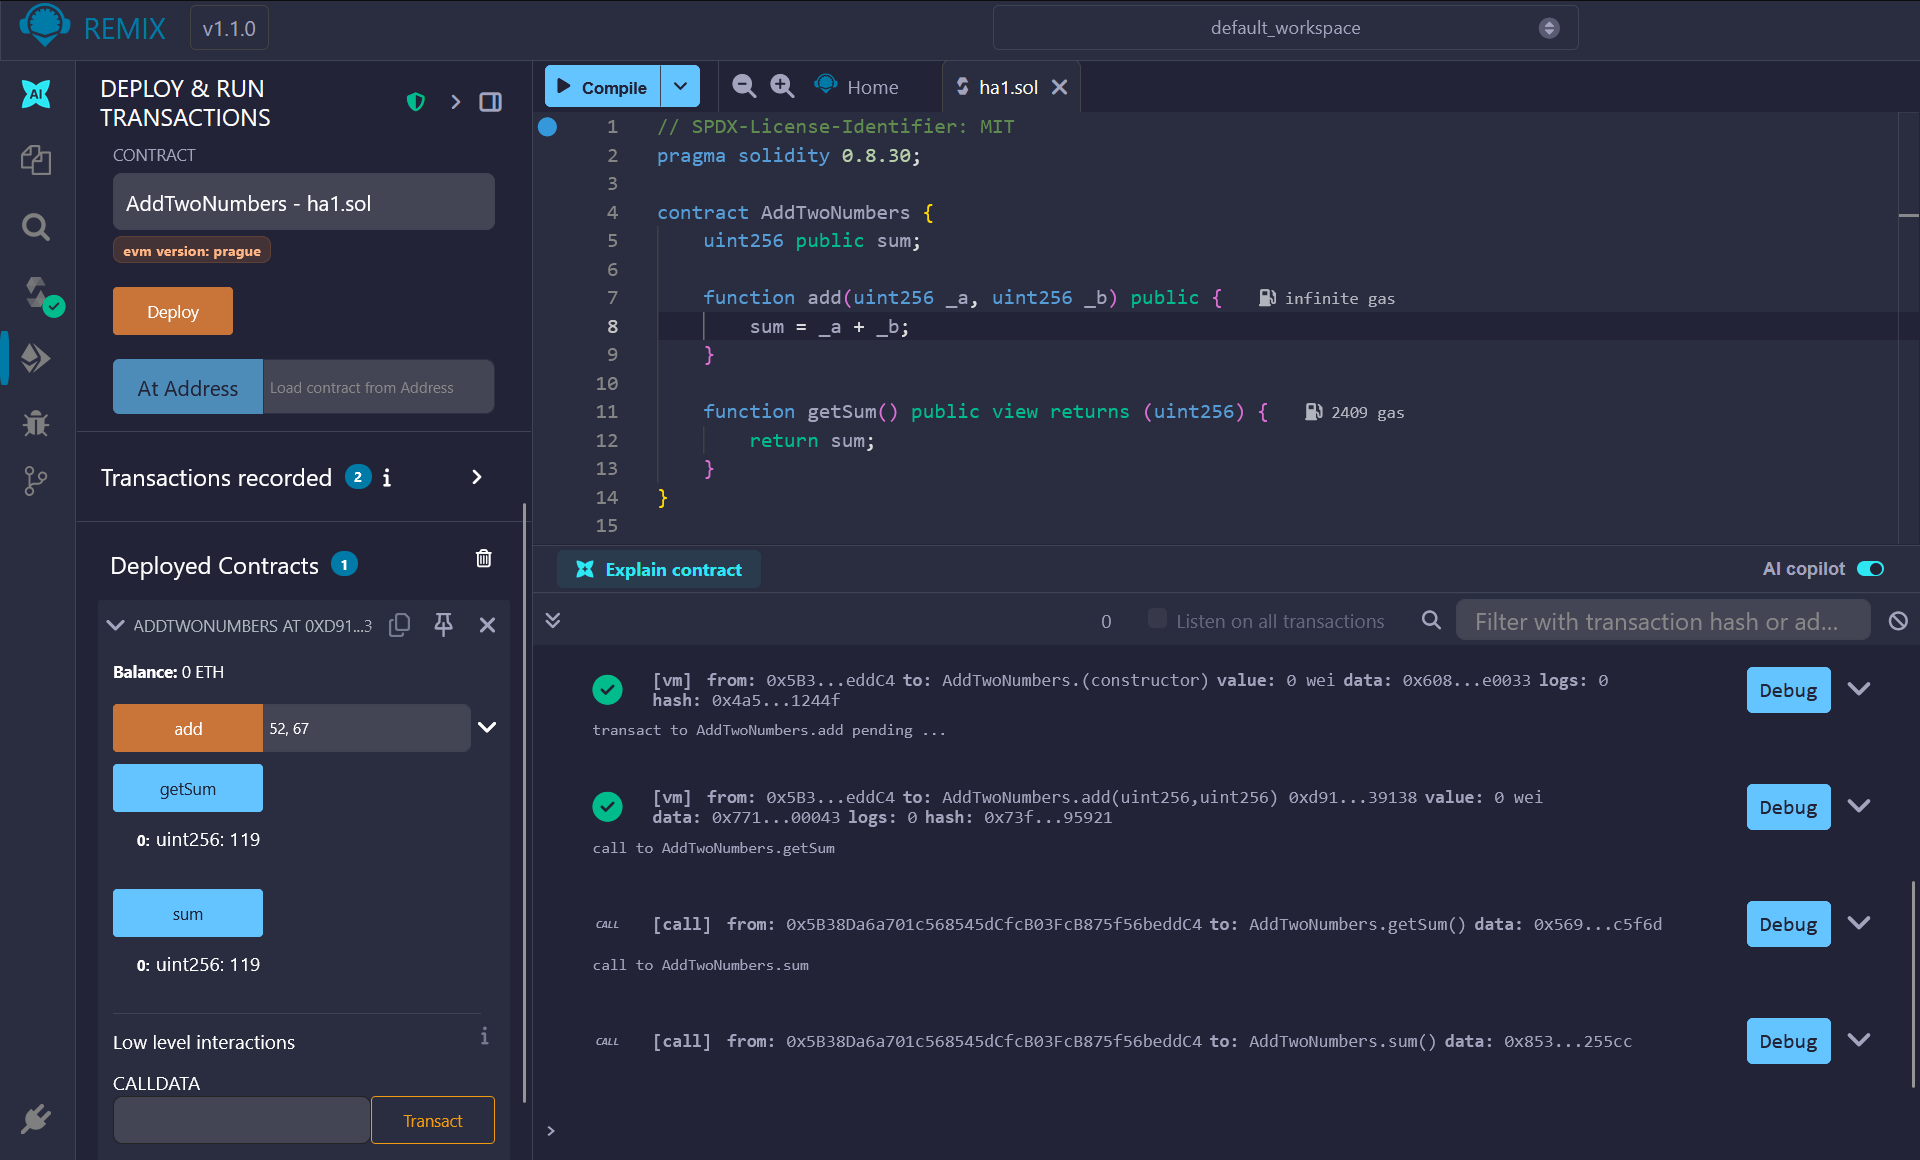

6 task:

contract creation transaction_id: 0x22753d52748d51a8bbe7e788cfadced3095cf79a0ee271b5798757be6de5048f
contract address: 0xe9f07995c1b37114af8df70d65fd70938f42eaf0
3-letter abbreviation of your coin: DPR

transaction ID to 0x80773c866332a7f3CFdD583d0b3A96655F035d6C: 0xbc9f1ce06754251139fbd6a8c76a6f02036d1c180bfa7135bfadb8f492f3737a

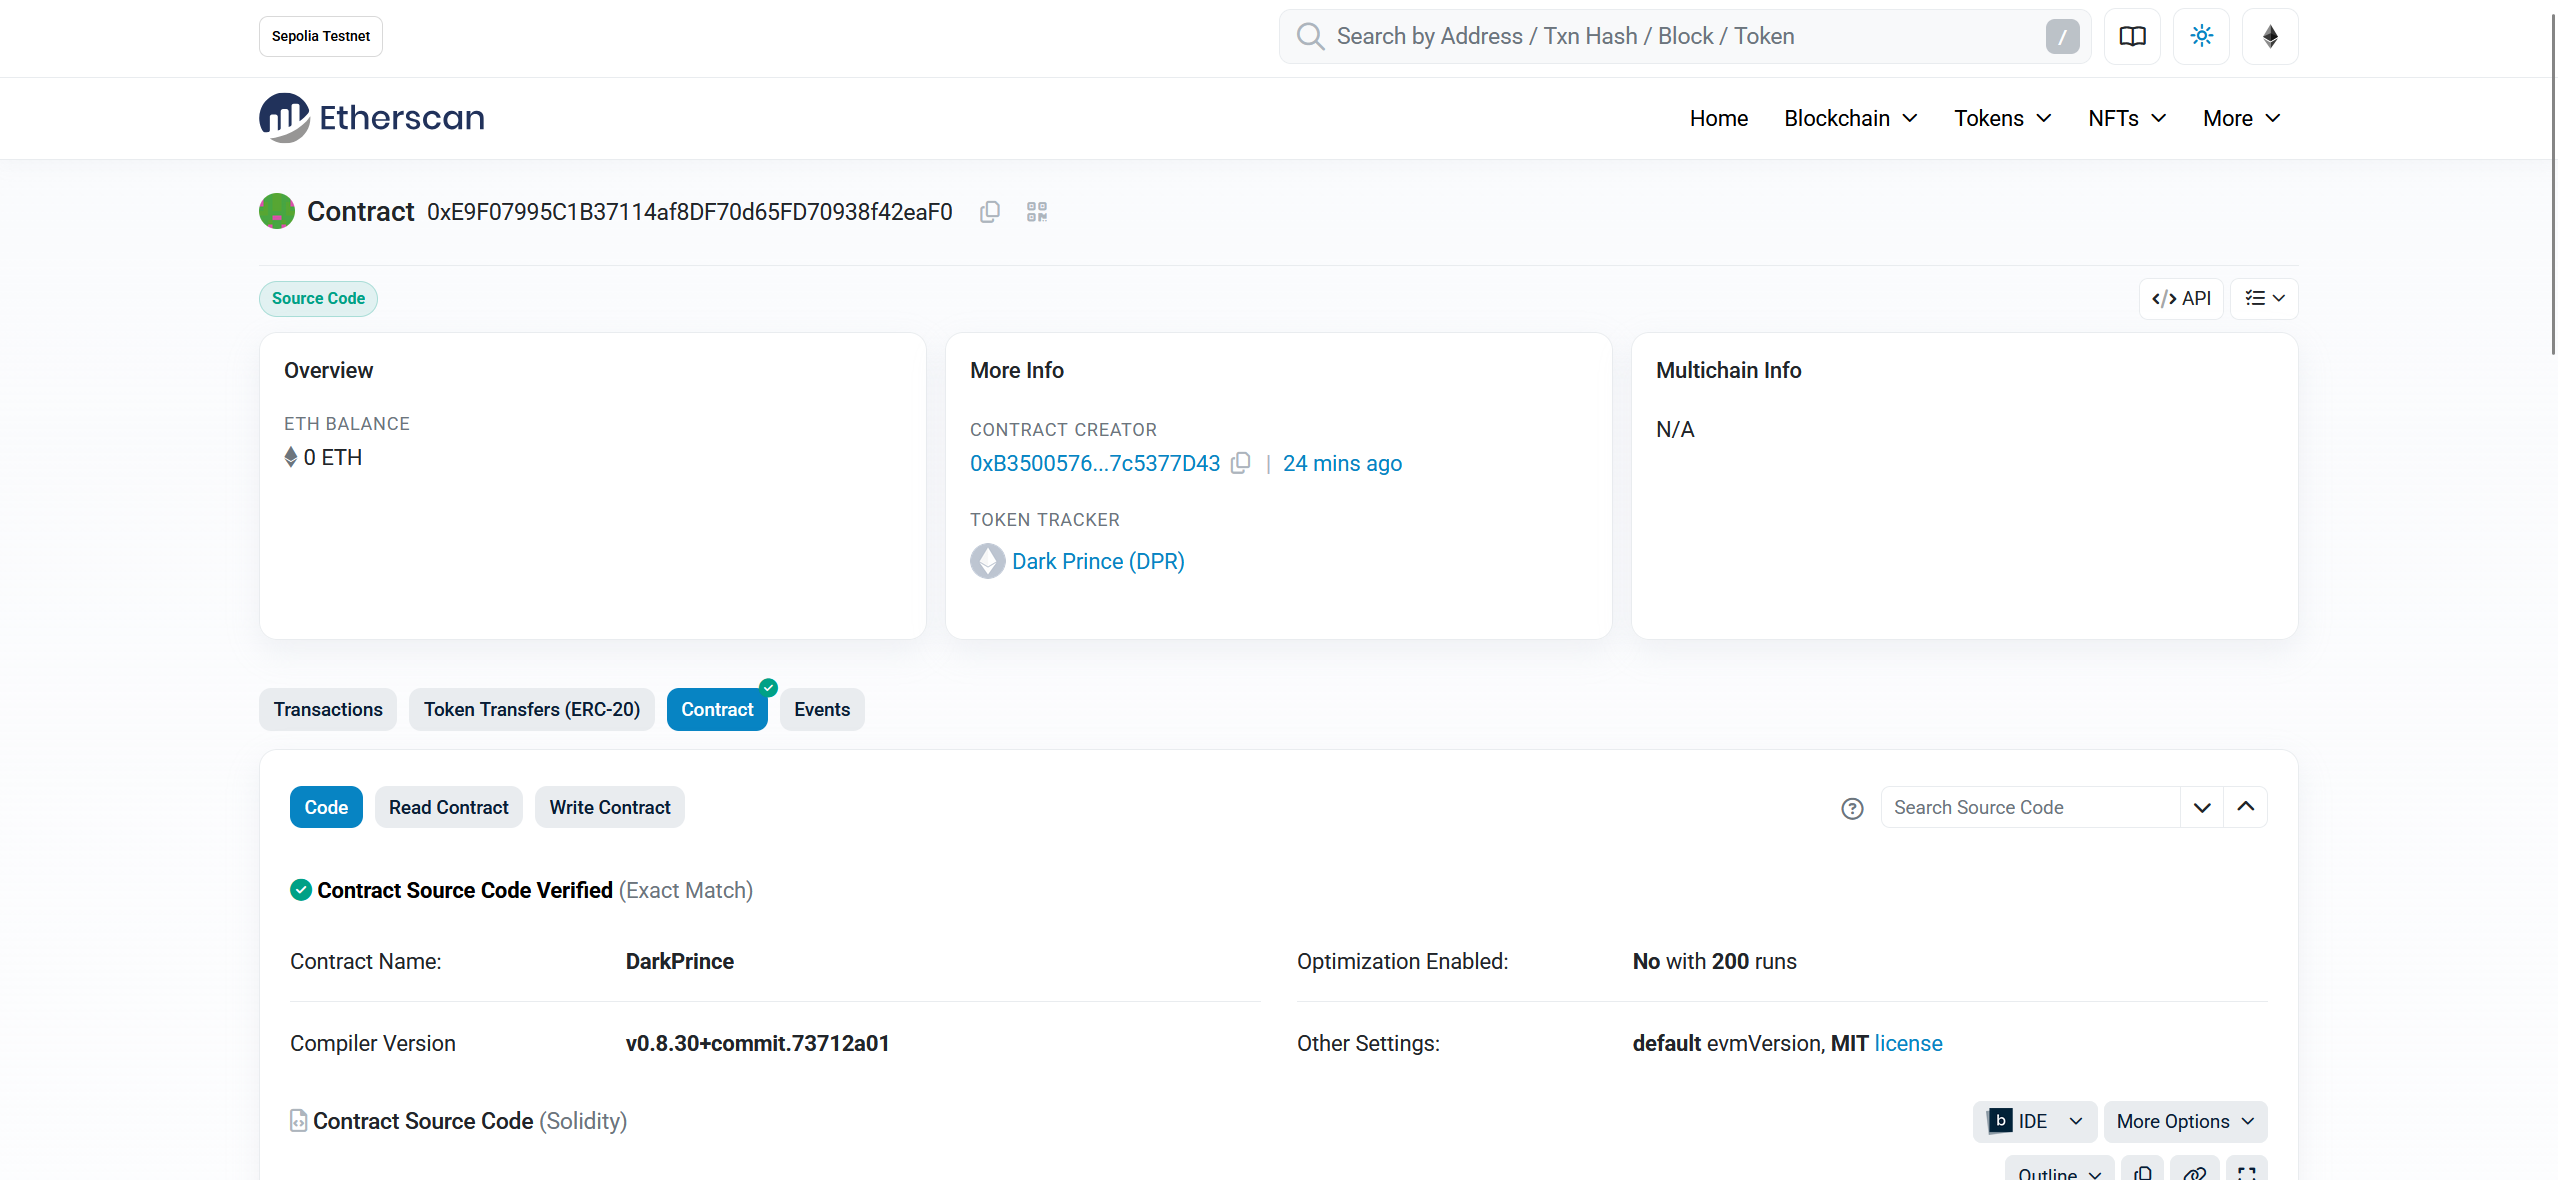